# Clasificación de Mensajes de Odio (Hate Speech Detection)
**Autor:** Gregory Harutyuyan Gevorgyan | **Dominio:** NLP / Clasificación Binaria

**Resumen:**
Este notebook orquesta el pipeline de modelado para la detección de mesajes de odio. Las fases incluyen un Análisis Exploratorio (EDA), la evaluación comparativa entre modelos lineales (Regresión Logística) y topológicos (LightGBM), la optimización del modelo seleccionado y la auditoría final de explicabilidad mediante valores SHAP.

*Para el detalle de las variables, consultar `DATA_DICTIONARY.md`.*

<hr>

## 1. ANÁLISIS EXPLORATORIO (EDA) Y FEATURE ENGINEERING

In [1]:
# Carga automática de módulos externos (autoreload)
%load_ext autoreload
%autoreload 2

### **1.1. Preprocesado del dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

In [3]:
from src.data_prep import load_and_audit_data

FILEPATH = "../data/raw/dataset_hate_speech.csv"  # Definimos la ruta de nuestro archivo CSV
df, info_df = load_and_audit_data(FILEPATH)

# Mostramos el resultado de la auditoría
display(info_df)

✅ Shape inicial: 10000 filas | 22 columnas.
⚠️ ALERTA: 539 filas duplicadas detectadas. Esto sesgará la validación.


,Dtype,Nulos_NaN,Nulos_Vacios,Unicos
A,int64,0,0,17
B,int64,0,0,189
C,int64,0,0,66
D,int64,0,0,7
E,int64,0,0,7
comentario,object,0,0,9461
label,int8,0,0,2
A_t,float64,0,0,17
B_t,float64,0,0,189
C_t,float64,0,0,66


A pesar de que las especificaciones previas del dataset indicaban que los duplicados habían sido tratados, la auditoría revela la existencia de 539 registros duplicados (aprox. 5.4% del volumen total).

Mantener estos registros introduce un alto riesgo de Data Leakage en la fase de modelado. 

**Decisión**: Se procederá a la eliminación de estos registros antes de iniciar cualquier análisis exploratorio.

In [4]:
# Eliminamos los duplicados
df = df.drop_duplicates().reset_index(drop=True)

print(f"✅ Limpieza ejecutada. Nuevo shape del dataset: {df.shape[0]} filas | {df.shape[1]} columnas.")

✅ Limpieza ejecutada. Nuevo shape del dataset: 9461 filas | 22 columnas.


In [5]:
pd.set_option('display.max_columns', None)
df.head(-5)

,A,B,C,D,E,comentario,label,A_t,B_t,C_t,D_t,E_t,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
0,2,64,30,0,2,"pandemia,originado,covid,cierto,incidencia,aba...",0,1.851102,2.759647,7.145831,-0.416577,0.440638,5.108388,13.227660,-0.771127,0.815665,19.719970,-1.149606,1.216004,-2.976790,3.148722,-0.183560
1,4,70,21,0,0,"ser,mes,larga,espera,llegar,momento,siempre,pr...",0,3.990202,3.054765,4.877255,-0.416577,-0.531099,12.189130,19.461233,-1.662227,-2.119191,14.898871,-1.272546,-1.622382,-2.031754,-2.590305,0.221244
2,4,88,50,0,0,"cartagena,san,sebastiar,fuengirola,irun,orense...",0,3.990202,3.940120,12.187108,-0.416577,-0.531099,15.721875,48.629021,-1.662227,-2.119191,48.018675,-1.641365,-2.092593,-5.076872,-6.472559,0.221244
3,3,38,21,0,0,"pleno,dia,verano,calor,plan,mas,apetecibl,disf...",0,2.920652,1.480801,4.877255,-0.416577,-0.531099,4.324903,14.244765,-1.216677,-1.551155,7.222244,-0.616868,-0.786452,-2.031754,-2.590305,0.221244
4,0,59,17,0,0,"pasado,junio,celebro,dia,luchar,frente,leishma...",0,-0.287998,2.513715,3.869000,-0.416577,-0.531099,-0.723945,-1.114264,0.119973,0.152955,9.725563,-1.047156,-1.335031,-1.611737,-2.054821,0.221244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9451,1,1,2,0,1,"serio,hablar,bori,vulgaridad,arrogante,penar,g...",1,0.781552,-0.339096,0.088042,-0.416577,-0.045231,-0.265021,0.068809,-0.325577,-0.035350,-0.029855,0.141260,0.015337,-0.036676,-0.003982,0.018842
9452,0,2,1,1,6,"enserio,@borisizaguirre,escribi,semejante,burr...",1,-0.287998,-0.289909,-0.164022,1.500246,2.384111,0.083493,0.047238,-0.432068,-0.686619,0.047552,-0.434935,-0.691176,-0.246074,-0.391047,3.576752
9453,0,0,1,0,6,"envidioso,",1,-0.287998,-0.388282,-0.164022,-0.416577,2.384111,0.111824,0.047238,0.119973,-0.686619,0.063687,0.161750,-0.925708,0.068328,-0.391047,-0.993166
9454,0,2,2,0,6,"titulo,propio,envidioso,resentido,social,",1,-0.287998,-0.289909,0.088042,-0.416577,2.384111,0.083493,-0.025356,0.119973,-0.686619,-0.025524,0.120770,-0.691176,-0.036676,0.209901,-0.993166


### **1.2. Aclaraciones de algunas variables**

#### I. Variable objetivo: 'label'

Investigamos acerca del etiquetado de la variable obetivo...

In [6]:
import pandas as pd

# Fijamos una semilla para reproducibilidad
SEED = 42

print("--------------------------")
print("AUDITORÍA DE ETIQUETAS ")
print("--------------------------")


# Extraemos 5 muestras aleatorias de la Clase 1
print("\n--> MUESTRAS DE LA CLASE [ 1 ]:")
for texto in df[df['label'] == 1]['comentario'].sample(5, random_state=SEED):
    print(f"- {texto}")

print("\n--------------------------------------------------\n")

# Extraemos 5 muestras aleatorias de la Clase 0
print("--> MUESTRAS DE LA CLASE [ 0 ]:")
for texto in df[df['label'] == 0]['comentario'].sample(5, random_state=SEED):
    print(f"- {texto}")

--------------------------
AUDITORÍA DE ETIQUETAS 
--------------------------

--> MUESTRAS DE LA CLASE [ 1 ]:
- alimentar,odio,suspicazmente,bastante,energumeno,esperar,buscar,culpable,periodismo,manipulador,mediatico,odio,
- imbecil,creer,mentira,
- pues,ver,cortar,polla,hincar,sacacorchos,ojo,
- menudo,payaso,
- pedazo,golfo,poco,

--------------------------------------------------

--> MUESTRAS DE LA CLASE [ 0 ]:
- informado,ultimo,hora,hoy,esencial,conocer,mundo,rodear,demasiado,tiempo,abc,poner,disposicion,lector,desear,mejor,resumen,sabado,julio,aqui,mismo,espectacular,hallazgo,sarcofago,epocar,visigoda,posiblemente,siglo,necropolis,villa,romano,villarico,mulo,murcia,asombrado,equipo,investigacion,universidad,murcia,liderado,catedratico,historia,antiguo,rafael,gonzalez,fernandez,habio,comenzado,lunes,campaña,centrar,ultima,tres,tumba,quedar,excavar,dia,siguiente,llevar,sorpresa,campana,repicar,despedir,muerto,espantar,tormenta,,llevar,apreciar,sonido,pequeño,atraen,beber,produci

**Confirmación**: La 'clase 0' corresponde con los comenarios SIN ODIO y la 'clase 1' corresponde con los comentarios CON ODIO.

#### II. Variables predictoras


Visualizamos las categorías de la variable 'E':

In [7]:
print(f"La variable 'E' contiene estas etiquetas: {df["E"].unique()}")

La variable 'E' contiene estas etiquetas: [2 0 1 6 3 4 5]


Comprobamos cómo se han generado las variables 'Valor_i':

In [8]:
import itertools

COLS_t = ["A_t","B_t","C_t","D_t","E_t"]

row = df.loc[0]

for i, (c1,c2) in enumerate(itertools.combinations(COLS_t, 2), 1):
    product = row[c1]*row[c2]
    real = row[f"Valor_{i}"]

    check = np.isclose(product, real)

    print(f"Valor_{i:02d} --> {c1} * {c2} = {product:.5f} | real={real:.5f} | match: {check}")

Valor_01 --> A_t * B_t = 5.10839 | real=5.10839 | match: True
Valor_02 --> A_t * C_t = 13.22766 | real=13.22766 | match: True
Valor_03 --> A_t * D_t = -0.77113 | real=-0.77113 | match: True
Valor_04 --> A_t * E_t = 0.81567 | real=0.81567 | match: True
Valor_05 --> B_t * C_t = 19.71997 | real=19.71997 | match: True
Valor_06 --> B_t * D_t = -1.14961 | real=-1.14961 | match: True
Valor_07 --> B_t * E_t = 1.21600 | real=1.21600 | match: True
Valor_08 --> C_t * D_t = -2.97679 | real=-2.97679 | match: True
Valor_09 --> C_t * E_t = 3.14872 | real=3.14872 | match: True
Valor_10 --> D_t * E_t = -0.18356 | real=-0.18356 | match: True


- La variable E representa el índice de sentimiento según la librería 'pysentimiento', codificada como: 
{
  0: 'anger',
  1: 'disgust',
  2: 'fear',
  3: 'joy',
  4: 'sadness',
  5: 'surprise',
  6: 'others'
}.
  -  **Posible error de diseño del dataset**: la variable E (Sentimiento) es de naturaleza categórica nominal (pendiente de análisis para comprobar si existe relación de ordinalidad). Su estandarización a E_t y posterior multiplicación con variables continuas carece de sentido matemático. Los términos de interacción generados a partir de E_t probablemente introducirán ruido en el modelo y son candidatos a ser eliminados durante la fase previa al modelado

- Las variables Valor_1 a Valor_10 corresponden a los términos del producto cruzado entre cada par de características estandarizadas. Respecto a su utilidad cabe destacar:

  - Con estas variables se dota a los algoritmos lineales de la capacidad de trazar límites de **separación no lineales**. Sin embargo, si se opta por modelos de árboles de decisión, estas variables introducen redundancia, dado que dichos algoritmos modelan las iteracciones de forma nativa.

  - **Riesgo de Multicolinealidad**: La creación de variables producto induce alta colinealidad con sus variables de origen, lo que exigirá regularización (Lasso/Ridge) para estabilizar la varianza de los pesos antes de aplicar métodos lineales.

### **1.3. Análisis de la variable objetivo**

In [9]:
TARGET = 'label'

--- Distribución de Clases ---
Clase 0: 52.53%
Clase 1: 47.47%
------------------------------


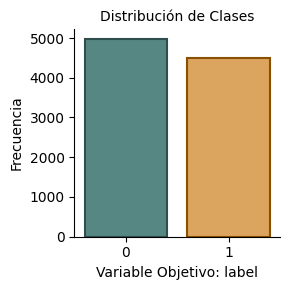

In [10]:
from src.plots import plot_distribucion_target

# Ejecutamos el análisis de la variable dependiente
plot_distribucion_target(df, target_col=TARGET)

**Métricas de Evaluación:** La ausencia de un desbalanceo entre las clases nos permite utilizar **Accuracy** y **ROC‑AUC** como métricas fiables para ajustar los modelos. Aun así, seguiremos revisando el **F1‑Score Macro** para asegurarnos de que tanto la *precisión* como el *recall* se mantienen sólidos en ambas clases y que el modelo funciona bien en todos los casos.


--- Auditoría Avanzada del Target: 'label' ---
🎯 Baseline (Zero Rule): 52.53%
   (Cualquier modelo de ML debe superar este Accuracy prediciendo la clase 0)
✅ Integridad Lógica: 0 contradicciones detectadas entre características y etiquetas.
--------------------------------------------------


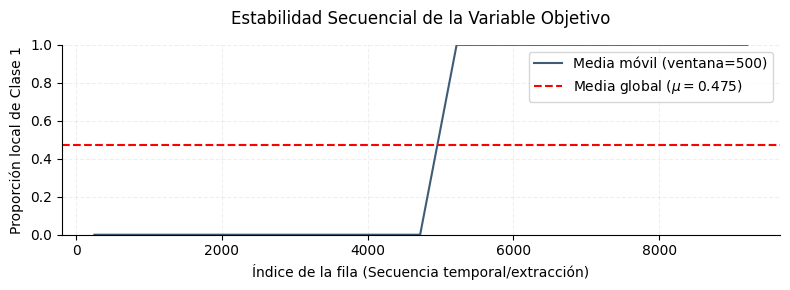

In [11]:
from src.data_prep import auditar_calidad_target
from src.plots import plot_estabilidad_secuencial

# 1. Auditoría matemática y Baseline
baseline, contradicciones = auditar_calidad_target(df, target_col=TARGET)

# 2. Análisis de Estacionariedad
# Usamos una ventana de 500 muestras para suavizar el ruido
plot_estabilidad_secuencial(df, target_col=TARGET, window=500)

**1. Baseline (Zero Rule)**
- El baseline calculado para este dataset es **52.53%**.  
- Esto representa el rendimiento mínimo que debe superar cualquier modelo para demostrar que está aprendiendo patrones reales y no simplemente replicando la clase mayoritaria.


**2. Bayes Error (Contradicciones en el etiquetado)**
- Se han encontrado **0 contradicciones** (vectores de características idénticos con etiquetas distintas).  
- Esto sugiere que, dentro del dataset observado, **no hay ruido intrínseco detectable en las etiquetas**, por lo que el límite teórico de rendimiento podría ser muy alto.


**3. Distribución secuencial de la variable objetivo**

Al analizar la proporción de la clase a lo largo del índice del dataset, se observa:

- Aproximadamente el primer 50% de las filas pertenece a la clase 0.
- El 50% restante pertenece a la clase 1.

**Implicación:** Si se realizara un `train_test_split` sin barajar los datos, el modelo:

- Entrenaría casi exclusivamente con ejemplos de la clase 0.
- Evaluaría casi exclusivamente con ejemplos de la clase 1.

**Decisión:** Se aplica un *shuffle aleatorio* al dataset para garantizar que ambas clases queden mezcladas antes de cualquier partición.


In [12]:
# 1. Permutación aleatoria global de la matriz de datos
# frac=1: Selecciona el 100% de las filas (no perdemos datos, solo los reordenamos)
# random_state=42: Fija la semilla para garantizar la reproducibilidad
df = df.sample(frac=1, random_state=42)

# 2. Reconstrucción del índice
# Es necesario resetear el índice y eliminar el antiguo para que las transformaciones
# posteriores (como concatenaciones o joins) no hereden la estructura anterior.
df = df.reset_index(drop=True)

print(f"✅ Dataset barajado y saneado. Shape actual: {df.shape[0]} filas | {df.shape[1]} columnas.")

✅ Dataset barajado y saneado. Shape actual: 9461 filas | 22 columnas.


--- Auditoría Avanzada del Target: 'label' ---
🎯 Baseline (Zero Rule): 52.53%
   (Cualquier modelo de ML debe superar este Accuracy prediciendo la clase 0)
✅ Integridad Lógica: 0 contradicciones detectadas entre características y etiquetas.
--------------------------------------------------


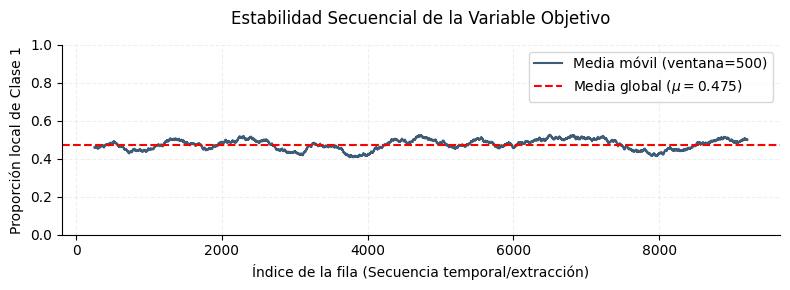

In [13]:
from src.data_prep import auditar_calidad_target
from src.plots import plot_estabilidad_secuencial

TARGET = "label"

# 1. Auditoría matemática y Baseline
baseline, contradicciones = auditar_calidad_target(df, target_col=TARGET)

# 2. Análisis de Estacionariedad
# Usamos una ventana de 500 muestras para suavizar el ruido
plot_estabilidad_secuencial(df, target_col=TARGET, window=500)

### **1.4. Análisis exploratorio del espacio de características**

#### I. Variables base numéricas

------ AUDITORÍA DE VARIABLES BASE NUMÉRICAS ------

Topología Univariante


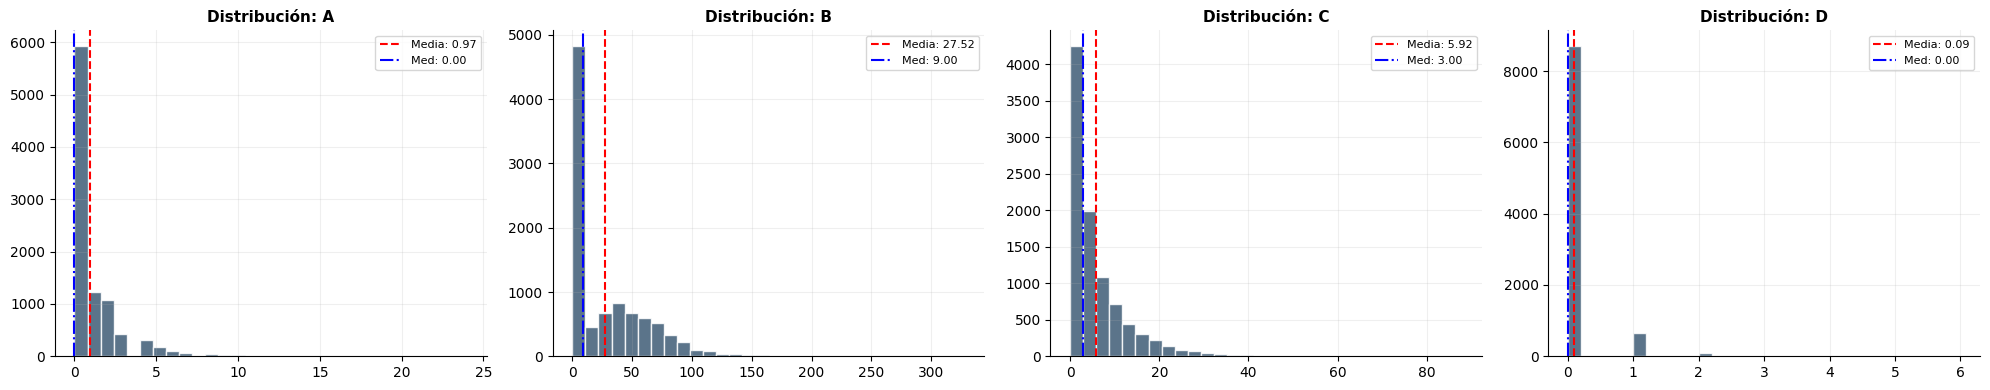

Densidad Discriminativa (Divergencia KL condicionada al Target)


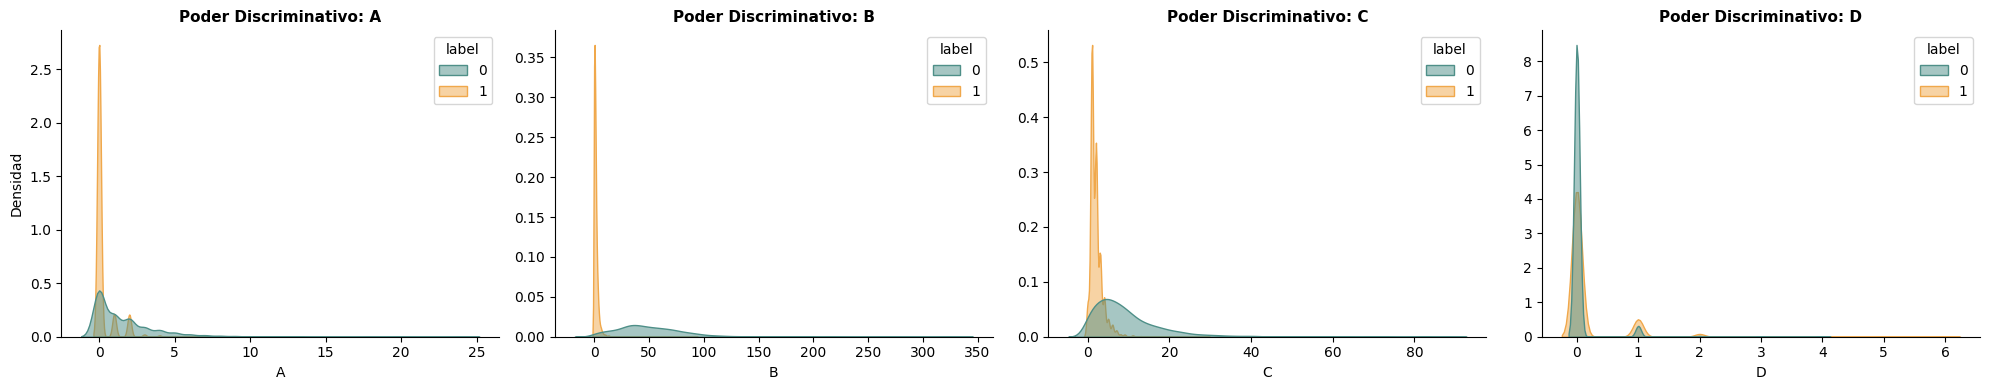

In [14]:
# Importamos las funciones desde nuestro módulo local
from src.plots import plot_distribucion_numericas, plot_densidad_predictiva

# Definimos el espacio de variables base a auditar
COLS_BASE_NUMERICAS = ["A", "B", "C", "D"]

print("------ AUDITORÍA DE VARIABLES BASE NUMÉRICAS ------\n")

print("Topología Univariante")
plot_distribucion_numericas(df, features=COLS_BASE_NUMERICAS, color_principal="#3E5C76")

print("Densidad Discriminativa (Divergencia KL condicionada al Target)")
plot_densidad_predictiva(df, features=COLS_BASE_NUMERICAS, target_col="label")

In [15]:
from src.data_prep import auditar_esparsidad

# Ejecutamos la auditoría sobre las características numéricas
df_esparsidad = auditar_esparsidad(df, features=COLS_BASE_NUMERICAS, umbral_alerta=60.0)

display(df_esparsidad)

,Caracteristica,Ceros_Pct
0,D,92.041010
1,A,62.710073
2,B,21.393087
3,C,5.295423


**1. Auditoría Topológica -->** *Asimetría y Zero-Inflation*

- Las variables **A, B, C y D** presentan una asimetría significativa hacia la derecha y un fenómeno severo de *Zero-Inflation*.

- La tabla de auditoría de esparsidad cuantifica este efecto: la variable **D** está vacía en un 92.04%, y la variable **A** en un 62.71%. Visualmente, esto se comprueba al observar cómo la media (línea roja) es desplazada por los valores atípicos de la cola, alejándose de la mediana (línea azul).

**Decisión:**
Evitar aplicar `StandardScaler` sobre estas distribuciones, ya que desplazaría el valor cero y **destruiría la esparsidad**, eliminando información relevante. En su lugar, es preferible emplear transformaciones robustas a *outliers* (como `RobustScaler` o `log`) y considerar que, ante este tipo de distribuciones altamente sesgadas y esparsas, los modelos basados en árboles suelen ofrecer una ventaja natural.

**2. Poder Discriminativo**

Al condicionar las densidades de probabilidad a la variable objetivo (`label`), se observa:

* **El poder de A, B y C:** Las gráficas muestran una separación clara. La clase 1 (naranja) se concentra casi por completo en el valor cero, mientras que la clase 0 (verde) se distribuye a lo largo de un rango más amplio, generando colas largas. Esto implica una alta ganancia de información.

* **Solapamiento de la variable D:** Las distribuciones de ambas clases en la variable D se superponen prácticamente por completo, lo que indica un bajo poder discriminativo.

**Decisión:**  
Se recomienda la eliminación de la variable **D**. Con un 92% de esparsidad y una capacidad nula para separar clases, su presencia solo añadiría ruido computacional e introduciría inestabilidad en los modelos.

In [16]:
# Extreamos características relevantes de los datos
tabla_resumen = df[COLS_BASE_NUMERICAS].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.99]).T
tabla_resumen = tabla_resumen[['count', 'min', '50%', '75%', '90%', '99%', 'max']]
tabla_resumen.rename(columns={'count': 'N', '50%': 'Mediana'}, inplace=True)
display(tabla_resumen.round(2))

,N,min,Mediana,75%,90%,99%,max
A,9461.0,0.0,0.0,1.0,3.0,8.0,24.0
B,9461.0,0.0,9.0,48.0,75.0,137.0,328.0
C,9461.0,0.0,3.0,8.0,15.0,35.0,88.0
D,9461.0,0.0,0.0,0.0,0.0,2.0,6.0


**3. Fronteras de Acotación**

La extracción de percentiles muestra el impacto de la cola larga de las distribuciones. Si observamos la diferencia entre el percentil 99 y el valor Máximo:

* La variable **B** salta bruscamente de $137.0$ a un máximo de $328.0$.
* La variable **C** salta de $35.0$ a $88.0$.
* La variable **A** salta de $8.0$ a $24.0$.

**Decisión**:  
Se establecen los valores P99 como umbrales para una futuro proceso de *Clipping*. Cualquier valor $x > P99$ será saturado al valor P99.

#### II. Variable base categórica

------ AUDITORÍA DE LA VARIABLE CATEGÓRICA ------


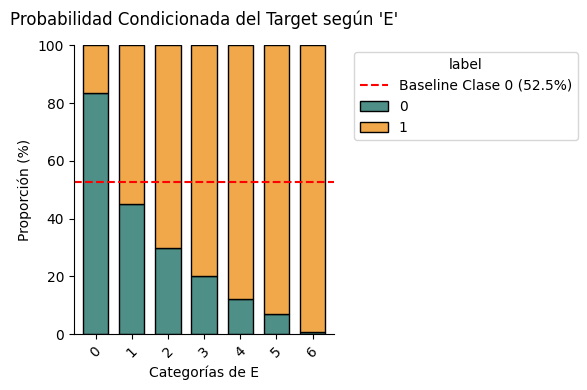

In [17]:
from src.plots import plot_categorica_proporcional

COLS_BASE_CATEGORICAS = "E" 

print("------ AUDITORÍA DE LA VARIABLE CATEGÓRICA ------")
plot_categorica_proporcional(df, cat_col=COLS_BASE_CATEGORICAS, target_col="label")

Existe una **relación monótona estricta** entre la magnitud de la variable `E` y la probabilidad de pertenecer a la clase 1 (naranja).

* Cuando `E` = 0, la clase 0 domina la distribución (probabilidad > 80%), situándose muy por encima del *baseline* del dataset (52.5%).
* A medida que aumenta el nivel de `E`, la clase 1 incrementa progresivamente su densidad de probabilidad.
* En los valores superiores (`E` = 5 y `E` = 6), la clase 1 representa prácticamente el 100% de los registros.

**Decisión:**  
Debido a la **ordinalidad estricta** detectada, se descarta aplicar **One-Hot Encoding** y se recomienda tratarla como variable ordinal.

**Consideración:** Se da visto bueno a las iteraciones con la variable `E` para generar nuevas columnas.

---

Para auditar el espacio de características (Valor_1 $\dots$ Valor_10), se omite el análisis univariante por redundancia topológica y se procede directamente a una auditoría matricial (Heatmap de Pearson) para detectar Fugas de Información y Colinealidad Crítica.

### **1.5. Multicolinealidad**

--- AUDITORÍA DE MULTICOLINEALIDAD ---


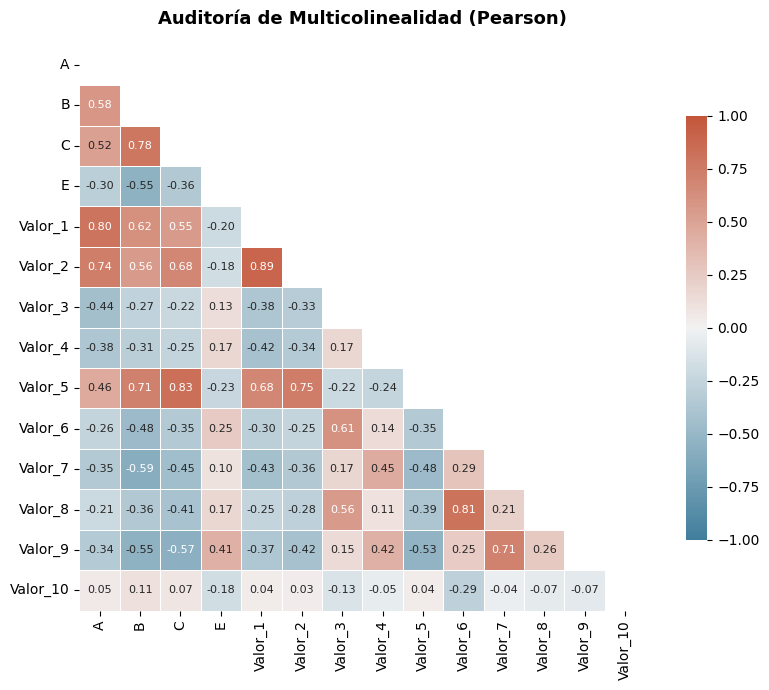

In [18]:
from src.plots import plot_matriz_correlacion

# Definimos el espacio de características, excluyendo 'D' (ya eliminada)
# y asumiendo que quieres auditar A, B, C, E y los 10 Valores
COLS_AUDITORIA = ["A", "B", "C", "E"] + [f"Valor_{i}" for i in range(1, 11)]

print("--- AUDITORÍA DE MULTICOLINEALIDAD ---")
plot_matriz_correlacion(df, features=COLS_AUDITORIA)

**Multicolinealidad Estructural (Pearson)**

Se selecciona el coeficiente de correlación de Pearson ($r$) para auditar la **proporcionalidad lineal** del espacio de características.

Fijando un umbral crítico de colinealidad en $|r| \geq 0.80$:
* **Redundancia entre variables:** `Valor_1` y `Valor_2` presentan una dependencia cuasi-perfecta ($r = 0.89$). Un patrón similar ocurre entre `Valor_8` y `Valor_6` ($r = 0.81$).
* **Solapamiento con variables base:** `Valor_5` se solapa con la variable `C` ($r = 0.83$) y `Valor_1` con `A` ($r = 0.80$).

**Decisión --> Reducción de Dimensionalidad:**
Para garantizar un modelo más simple y optimizar la complejidad espacial en el entrenamiento, se recomienda la purga para las características: **`Valor_1`**, **`Valor_2`**, **`Valor_5`** y **`Valor_8`(o `Valor_6`)**.

### <span style="color:#2F7597">**1.6. Conclusiones de la EDA y Directrices**</span>

#### 1. Topología Univariante: Asimetría y Zero-Inflation
* Las variables continuas base presentan una concentración masiva en $x=0$ y colas largas. Existe un salto considerable entre el percentil 99 (P99) y el valor máximo absoluto.
* **Decisión:** Se descarta la estandarización `StandardScaler`, dependiente de la media, para evitar destruir la esparsidad natural. Se añadirá al *pipeline* una capa de **Clipping en el P99** (durante el particionado de entrenamiento para evitar fugas) seguido de un `RobustScaler`, protegiendo así la estabilidad del descenso de gradiente en el *baseline* lineal.

#### 2. Ganancia de Información y Reducción de Dimensionalidad
* **Purga por Esparsidad:** La variable **`D`** presenta un 92% de valores nulos y nula divergencia distributiva condicionada al *target*. Queda eliminada del espacio de características.
* **Purga por Colinealidad:** La matriz de Pearson muestra que varias variables presentan una redundancia considerable ($|r| \geq 0.80$), consecuencia de las transformaciones aplicadas. Para evitar que la matriz de covarianza $(X^T X)^{-1}$ se vuelva inestable y que las métricas de importancia del modelo (como SHAP) pierdan fiabilidad, se eliminan las características **`Valor_1`**, **`Valor_2`**, **`Valor_5`** y **`Valor_8`**.

#### 3. Topología Ordinal y Monotonicidad
* La probabilidad condicionada muestra una relación monótona estricta entre la magnitud de la variable **`E`** y la probabilidad de pertenencia a la clase minoritaria $P(Y=1 | E)$.
* **Decisión:** Queda prohibido realizar *One-Hot Encoding*.

<hr>

## 2. SELECCIÓN Y ENTRENAMIENTO DE LOS MODELOS

### **2.1. Pipeline de Preprocesamiento**

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin
from src.evaluation import auditar_modelo

# 1. PURGAMOS LA VARIABLES SELECCIONADAS DURANTE LA EDA Y AQUELLAS INNECESARIAS
COLS_DROP = ['label', 'D', 'comentario', 'A_t', 'B_t', 'C_t', 'D_t', 'E_t', 'Valor_1', 'Valor_2', 'Valor_5'] # Más adelante decidimos si eliminar Valor_6 o Valor_8
X = df.drop(columns=COLS_DROP)
y = df['label']

# 2. PARTICIONADO ESTRATIFICADO
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. TRANSFORMADOR: CLIPPING
class P99Clipper(BaseEstimator, TransformerMixin):
    """
    Acota la cola larga extrema de las distribuciones.
    Aprende los umbrales SOLO en .fit() para evitar Data Leakage.
    """
    def __init__(self, percentile=99.0):
        self.percentile = percentile
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        # Cálculo sobre el conjunto de entrenamiento
        self.upper_bounds_ = np.percentile(X, self.percentile, axis=0)
        return self

    def transform(self, X, y=None):
        # Aplicación del límite
        return np.clip(X, a_min=None, a_max=self.upper_bounds_)

# 4. MAPEO DE CARACTERÍSTICAS
COLS_NUMERICAS = ['A', 'B', 'C', 'Valor_3', 'Valor_4', 'Valor_6', 'Valor_7', 'Valor_9', 'Valor_10'] # Optamos por eliminar la variable Valor_8
COLS_ORDINALES = ['E']

# 5. CONSTRUCCIÓN DEL PIPELINE
num_pipeline = Pipeline(steps=[
    ('clipper', P99Clipper(percentile=99.0)),
    ('scaler', RobustScaler())
])

preprocesador = ColumnTransformer(
    transformers=[
        ('num_transforms', num_pipeline, COLS_NUMERICAS),
        ('cat_ordinal', 'passthrough', COLS_ORDINALES)
    ],
    remainder='drop'
)

# 6. VALIDACIÓN DEL FLUJO
print(f"Dimensiones X_train crudo: {X_train.shape}")
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)
print(f"Dimensiones X_train procesado: {X_train_procesado.shape}")

Dimensiones X_train crudo: (7568, 11)
Dimensiones X_train procesado: (7568, 10)


In [20]:
df.to_csv('../data/processed/dataset_hate_speech_cleaned.csv', index=False)

### **2.2. Regresión Logística ElasticNet**

#### I. Entrenamiento del Baseline

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definición del Modelo Baseline --> ElasticNet
modelo_base = LogisticRegression(
    solver='saga', # Único algoritmo que soporta 'elastiknet'
    l1_ratio=0.5, # 50% Lasso (fuerza esparsidad) y 50% Ridge (controla multicolinealidad residual)
    max_iter=2000, # Amplio para garantizar convergencia del gradiente
    random_state=42
)

# 2. Ensamble del Pipeline
pipeline_lr = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', modelo_base)
])

pipeline_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transforms', ...), ('cat_ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [22]:
# 3. Validación Cruzada Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 4. Definimos el diccionario con las métricas seleccionadas durante la EDA
metricas = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

# 5. Ejecutamos la Validación Cruzada y auditamos los resultados
cv_results = auditar_modelo(
    pipeline=pipeline_lr,
    X=X_train,
    y=y_train,
    cv=skf,
    metricas=metricas,
    nombre_modelo="Baseline ElasticNet"
)

Entrenando Baseline ElasticNet con Validación Cruzada...

-------------------------------
MÉTRICAS DE VALIDACIÓN CRUZADA: BASELINE ELASTICNET
-------------------------------
- ROC-AUC  : 0.9944 (+/- 0.0022)
- Accuracy : 0.9738 (+/- 0.0029)
- F1-Macro : 0.9738 (+/- 0.0029)

--------------------------------------
AUDITORÍA DE SOBREAJUSTE (TRAIN vs VAL)
--------------------------------------
- Accuracy Gap : Train (0.9740) vs Val (0.9738) -> Diferencia: 0.0001
- ROC-AUC Gap  : Train (0.9949) vs Val (0.9944) -> Diferencia: 0.0005


**Evaluación del Baseline --> Regresión Logística ElasticNet**

Los resultados de la validación cruzada en el modelo base revelan un rendimiento excepcionalmente alto:

* **Discriminación algorítmica:** Un ROC-AUC de 0.9944 indica una separabilidad lineal cuasi-perfecta entre las clases.
* **Robustez:** El hecho de que Accuracy y F1‑Macro sean prácticamente iguales (0.9738) indica que el modelo funciona igual de bien para ambas clases. Además, la baja variabilidad entre folds confirma que el rendimiento es sólido y no depende de la partición de los datos.

**¡Advertencia!**: Un *baseline* paramétrico con un rendimiento superior al 99% es un indicio que merece revisarse con cuidado. Esto suele ocurrir en dos situaciones: o bien las variables explicativas están tan fuertemente relacionadas con la variable objetivo que el problema resulta casi trivial, o existe algún tipo de fuga de información (Target Leakage) que está facilitando al modelo un acceso indirecto a la respuesta correcta.

Antes de dar por válidas estas métricas o pasar a modelos más complejos, es importante revisar a fondo la Regresión Logística. Para ello, conviene analizar la magnitud de sus coeficientes y comprobar que ninguna variable esté actuando como un sustituto directo de la etiqueta, lo que podría indicar un problema de fuga de información.

#### II. Auditoría de coeficientes

In [23]:
# 1. Ajustamos el pipeline final con todo el conjunto de entrenamiento
pipeline_lr.fit(X_train, y_train)

# 2. Extraemos el estimador (el modelo matemático) de dentro del pipeline
modelo_entrenado = pipeline_lr.named_steps['modelo']

# 3. Extraemos los coeficientes (Pesos W)
pesos_w = modelo_entrenado.coef_[0]

# 4. Reconstruimos los nombres de las columnas (numéricas + ordinal)
nombres_columnas = COLS_NUMERICAS + COLS_ORDINALES

# 5. Creamos un DataFrame para auditar la importancia de forma estructurada
df_auditoria_pesos = pd.DataFrame({
    'Característica': nombres_columnas,
    'Peso_W': pesos_w,
    'Magnitud_Absoluta': np.abs(pesos_w)
})

# Ordenamos por la magnitud del impacto (de mayor a menor)
df_auditoria_pesos = df_auditoria_pesos.sort_values(by='Magnitud_Absoluta', ascending=False).reset_index(drop=True)

print("------------------------------------------------")
print("AUDITORÍA DE COEFICIENTES (REGRESIÓN LOGÍSTICA)")
print("------------------------------------------------")
print(df_auditoria_pesos)

------------------------------------------------
AUDITORÍA DE COEFICIENTES (REGRESIÓN LOGÍSTICA)
------------------------------------------------
  Característica     Peso_W  Magnitud_Absoluta
0              B -15.848565          15.848565
1              C   2.164877           2.164877
2        Valor_7   1.041914           1.041914
3              E   0.800146           0.800146
4        Valor_6  -0.482270           0.482270
5       Valor_10  -0.301256           0.301256
6              A   0.273226           0.273226
7        Valor_9  -0.110028           0.110028
8        Valor_4  -0.105602           0.105602
9        Valor_3  -0.042590           0.042590


**Revisión de Coeficientes**

La revisión de los coeficientes muestra que la variable `B` (conteo absoluto de palabras negativas) destaca de forma anómala, con un peso de -15.85. En la práctica, esto significa que el modelo ha aprendido que “cuantas más palabras negativas aparecen en un texto, menor es la probabilidad de que sea un mensaje de odio”, lo cual resulta claramente contradictorio.

**Interpretación:** Al revisar manualmente el corpus se observa que los textos de la Clase 0 (No Odio) suelen ser más largos, mientras que los de la Clase 1 (Odio) tienden a ser mensajes breves, muchas veces insultos directos. Como `B` es un conteo absoluto, está reflejando la longitud del documento, no su carga emocional.

**Decisión:**  
- Mantener esta variable introduce un riesgo claro de fuga de información y hace que el modelo sea poco fiable. Por ejemplo, un **mensaje de odio largo** podría clasificarse erróneamente como “No Odio” debido al peso negativo exagerado de `B`. Por este motivo, se decide eliminar la variable del *pipeline* (renunciar a la métrca artificialmente alta del 0.99) para obligar al modelo a apoyarse en señales semánticas reales y enriquecer los criterios de decisión del modelo.
- También se eliminarán las variables derivadas de `B`. Aunque podría resultar interesante analizar su impacto suavizado en un modelo lineal mediante la interacción con el resto de variables, en los modelos basados en árboles dicho efecto se revierte: la fuerte capacidad discriminativa de `B` vuelve a dominar y termina contaminando el modelo.
- Entonces, a parte de la variable `B`, se eliminarán también: `Valor_1`, `Valor_5`, `Valor_6` y `Valor_7`.
- **Consideración:** Se optó por eliminar la variable `Valor_8` y se mantuvo `Valor_6` debido a la fuerte colinealidad entre ellas --> se cambia la decisión y se procede a eliminar `Valor_6`y mantener `Valor_8`.

#### III. Iteración 2: Reentrenamiento con Espacio de Características Actualizado

In [24]:
# 1. Actualizamos la lista de características numéricas (sin 'B', sin sus derivadas y añadiendo 'Valor_8')
COLS_NUMERICAS_V2 = ['A', 'C', 'Valor_3', 'Valor_4', 'Valor_8', 'Valor_9', 'Valor_10'] 

COLS_DROP_V2 = ['label', 'B', 'D', 'Valor_1', 'Valor_2', 'Valor_5', 'Valor_6', 'Valor_7']

# 2. Purgamos la variable seleccionada
X_train_v2 = X_train.drop(columns=COLS_DROP_V2, errors='ignore')
X_test_v2  = X_test.drop(columns=COLS_DROP_V2, errors='ignore')


# 3. Reensamblamos el ColumnTransformer con la nueva lista
preprocesador_v2 = ColumnTransformer(
    transformers=[
        ('num_transforms', num_pipeline, COLS_NUMERICAS_V2),
        ('cat_ordinal', 'passthrough', COLS_ORDINALES)
    ],
    remainder='drop'
)

# 4. Reensamblamos el Pipeline final
pipeline_lr_v2 = Pipeline(steps=[
    ('preprocesador', preprocesador_v2),
    ('modelo', modelo_base) # Usamos la misma configuración de LogisticRegression
])

pipeline_lr_v2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transforms', ...), ('cat_ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [25]:
# 5. Ejecutamos la Validación Cruzada y auditamos los resultados
cv_results_v2 = auditar_modelo(
    pipeline=pipeline_lr_v2,
    X=X_train_v2,
    y=y_train,
    cv=skf,
    metricas=metricas,
    nombre_modelo="Baseline ElasticNet (Post-Purga)"
)

Entrenando Baseline ElasticNet (Post-Purga) con Validación Cruzada...

-------------------------------
MÉTRICAS DE VALIDACIÓN CRUZADA: BASELINE ELASTICNET (POST-PURGA)
-------------------------------
- ROC-AUC  : 0.9695 (+/- 0.0022)
- Accuracy : 0.8938 (+/- 0.0180)
- F1-Macro : 0.8933 (+/- 0.0185)

--------------------------------------
AUDITORÍA DE SOBREAJUSTE (TRAIN vs VAL)
--------------------------------------
- Accuracy Gap : Train (0.8953) vs Val (0.8938) -> Diferencia: 0.0015
- ROC-AUC Gap  : Train (0.9699) vs Val (0.9695) -> Diferencia: 0.0005


Las métricas bajan ligeramente respecto a la versión pre-purga al eliminar la fuga de información (variable B y derivadas). Aún así, el rendimiento es sólido y **realista**: *ROC-AUC* de 0.9695 y *F1-Macro* de 0.8933. Esto demuestra una fuerte separabilidad lineal y establece un baseline estricto (*Accuracy* 89.38%) para comparar con el modelo de árboles.

#### IV. Iteración 2: Auditoría de coeficientes v2

In [26]:
import pandas as pd
import numpy as np

# 1. Ajustamos el pipeline V2 con todo el conjunto de entrenamiento purgado
pipeline_lr_v2.fit(X_train_v2, y_train)

# 2. Extraemos el modelo entrenado
modelo_entrenado_v2 = pipeline_lr_v2.named_steps['modelo']

# 3. Extraemos los nuevos coeficientes
pesos_w_v2 = modelo_entrenado_v2.coef_[0]

# 4. Reconstruimos los nombres (usando las constantes corregidas)
nombres_columnas_v2 = COLS_NUMERICAS_V2 + COLS_ORDINALES

# 5. Creamos el DataFrame de auditoría V2
df_auditoria_pesos_v2 = pd.DataFrame({
    'Caracteristica': nombres_columnas_v2,
    'Peso_W': pesos_w_v2,
    'Magnitud_Absoluta': np.abs(pesos_w_v2)
})

# Ordenamos
df_auditoria_pesos_v2 = df_auditoria_pesos_v2.sort_values(by='Magnitud_Absoluta', ascending=False).reset_index(drop=True)

print("----------------------------------------------")
print("AUDITORÍA DE COEFICIENTES V2 (ESPACIO PURGADO)")
print("----------------------------------------------")
print(df_auditoria_pesos_v2)

----------------------------------------------
AUDITORÍA DE COEFICIENTES V2 (ESPACIO PURGADO)
----------------------------------------------
  Caracteristica    Peso_W  Magnitud_Absoluta
0              C -3.053486           3.053486
1              E  1.010916           1.010916
2       Valor_10 -0.536792           0.536792
3              A -0.360436           0.360436
4        Valor_8  0.340531           0.340531
5        Valor_9  0.317316           0.317316
6        Valor_4  0.167862           0.167862
7        Valor_3 -0.096666           0.096666


**CONCLUSIÓN DE LA FASE 2**

Tras actualizar el conjunto de variables numéricas (eliminar la variable `B`, `Valor_1`, `Valor_6`, `Valor_7` y añadir `Valor_8`), que introducían una fuga de información relacionada con la longitud del texto, el modelo ajusta su *ROC‑AUC* de 0.9944 a 0.9695. Supone una redcución de la métrica a un valor más coherente y se ha conseguido un mayor enriquecimiento del criterio del modelo a la hora de descriminar. 

**1. Rendimiento equilibrado entre clases:**  
La coincidencia casi exacta entre el *Accuracy* y el *F1‑Macro* (ambos en 0.893) indica que el modelo trata por igual a la clase mayoritaria y a la minoritaria. El error se distribuye de forma uniforme, sin favorecer a una clase sobre la otra.

**2. Coeficientes más saludables (Auditoría V2):**  
El nuevo vector de pesos muestra que el modelo ya no depende de una única variable. La magnitud máxima, que antes alcanzaba 15.84, se reduce a un valor mucho más razonable de -3.05 (`C`). Además, la carga predictiva se reparte entre varias características (`C`, `E`, `Valor_10`, `A`, etc.), lo que demuestra que la decisión se construye a partir de señales más ricas y representativas del espacio de características.

**Veredicto:**  
La Regresión Logística con ElasticNet se consolida como un *baseline* sólido con un rendimiento muy alto.

### **2.3. Gradient Boosting: LightGBM**

Repaso de las variables que participan en el modelado:

In [27]:
X_train_v2.head(5)

,A,C,E,Valor_3,Valor_4,Valor_8,Valor_9,Valor_10
9269,0,3,0,0.119973,0.152955,-0.141680,-0.180630,0.221244
5921,0,1,3,0.119973,-0.266832,0.068328,-0.151968,-0.385961
9428,6,12,0,-2.553328,-3.255265,-1.086717,-1.385467,0.221244
6460,0,3,6,0.119973,-0.686619,-0.141680,0.810849,-0.993166
7190,0,4,0,0.119973,0.152955,-0.246684,-0.314500,0.221244


In [28]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

# 1. Configuración del Modelo de Gradiente Boosting
modelo_lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
)

# 2. Ensamble del Pipeline
# Reutilizamos el mismo preprocesador_v2. 
# Aunque los árboles son invariantes a la escala (no necesitan el RobustScaler),
# usar el mismo preprocesador garantiza una comparación justa entre los modelos.
pipeline_lgbm = Pipeline(steps=[
    ('preprocesador', preprocesador_v2),
    ('modelo', modelo_lgbm)
])

pipeline_lgbm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transforms', ...), ('cat_ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [29]:
# 3. Ejecutamos la Validación Cruzada y auditamos los resultados
cv_results_lgbm = auditar_modelo(
    pipeline=pipeline_lgbm,
    X=X_train_v2,
    y=y_train,
    cv=skf,
    metricas=metricas,
    nombre_modelo="LightGBM"
)

Entrenando LightGBM con Validación Cruzada...

-------------------------------
MÉTRICAS DE VALIDACIÓN CRUZADA: LIGHTGBM
-------------------------------
- ROC-AUC  : 0.9759 (+/- 0.0028)
- Accuracy : 0.9193 (+/- 0.0064)
- F1-Macro : 0.9189 (+/- 0.0064)

--------------------------------------
AUDITORÍA DE SOBREAJUSTE (TRAIN vs VAL)
--------------------------------------
- Accuracy Gap : Train (0.9289) vs Val (0.9193) -> Diferencia: 0.0096
- ROC-AUC Gap  : Train (0.9841) vs Val (0.9759) -> Diferencia: 0.0082


**Decisión**: Aunque la variable `E` muestra un comportamiento ordinal, se decide no usar `monotone_constraints`. Forzar una relación estrictamente creciente limitaría la flexibilidad del modelo para captar interacciones más complejas y podría introducir sesgos al impedir que aparezcan excepciones naturales en los datos.

### <span style="color:#2F7597">**2.4. Conclusiones del Modelado**</span>

**Comparativa Rápida: ElasticNet vs LightGBM**

| Métrica     | ElasticNet | LightGBM | Mejora |
|-------------|------------|----------|--------|
| ROC-AUC     | 0.9695     | 0.9759   |  +0.0064 |
| Accuracy    | 0.8938     | 0.9193   |  +0.0255 |
| F1-Macro    | 0.8933     | 0.9189   |  +0.0256 |
| Gap AUC     | 0.0005     | 0.0082   | — |
| Gap Acc     | 0.0015     | 0.0096   | — |

**Conclusiones:**

- **LightGBM supera claramente al baseline lineal** en todas las métricas importantes.  
- El salto en **Accuracy** y **F1-Macro** indica una mejora en la calidad de clasificación.  
- El ligero aumento del gap entre Train y Validación es **normal en modelos no lineales** y sigue dentro de márgenes seguros.  

En conjunto, el cambio supone un trade-off claro: ElasticNet ofrece un comportamiento muy estable y prácticamente sin sobreajuste, pero LightGBM aporta un salto real en capacidad predictiva gracias a su flexibilidad para capturar relaciones no lineales. Aceptamos un ligero aumento en el gap entre entrenamiento y validación porque el rendimiento adicional compensa con creces ese coste. En este punto, **LightGBM se posiciona como la opción más sólida para avanzar**.

<hr>

## 3. AJUSTE, EXPLICABILIDAD Y SERIALIZACIÓN

### **3.1. Optimización de Hiperparámetros**

#### I. Optimización Bayesiana

In [30]:
from src.evaluation import optimizar_lightgbm

# Ejecutamos el estudio TPE (Tree-structured Parzen Estimator) 
estudio_lgbm = optimizar_lightgbm(
    X=X_train_v2, 
    y=y_train, 
    preprocesador=preprocesador_v2, 
    cv=skf, 
    n_trials=100
)

# Auditoría
print("\n==========================================")
print(f"Mejor ROC-AUC en Validación Cruzada: {estudio_lgbm.best_value:.4f}")
print("Mejores Hiperparámetros Descubiertos:")
for clave, valor in estudio_lgbm.best_params.items():
    print(f" - {clave}: {valor}")
print("==========================================")

Iniciando Optimización Bayesiana con Optuna (TPE)...


  0%|          | 0/100 [00:00<?, ?it/s]


Mejor ROC-AUC en Validación Cruzada: 0.9791
Mejores Hiperparámetros Descubiertos:
 - n_estimators: 550
 - learning_rate: 0.011113808420578809
 - num_leaves: 27
 - max_depth: 3
 - min_child_samples: 33
 - subsample: 0.7819852073376351
 - colsample_bytree: 0.8324508669654009


**Optimización Bayesiana --> ROC-AUC (Validación Cruzada): 0.9790**

1. **Shrinkage Extremo:** Tasa de aprendizaje mínima ($LR \approx 0.01$) compensada con $550$ iteraciones para suavizar la frontera de decisión.
2. **Regularización Estocástica:** *Bagging* agresivo en filas (`subsample` $\approx 0.78$) para evitar la memorización de ruido local.
3. **Restricción Estructural:** Límite estricto en `max_depth = 3`, forzando el truncamiento matemático de las hojas a un máximo de $2^3 = 8$.

#### II. Diagnóstico de Convergencia (Early Stopping)

In [31]:
params_optimos = {
    'n_estimators': 550,
    'learning_rate': 0.011312,
    'num_leaves': 8, # Corregido por la restricción topológica: 2^max_depth (2^3)
    'max_depth': 3,
    'min_child_samples': 33,
    'subsample': 0.781985,
    'colsample_bytree': 0.832451,
    'random_state': 42,
    'n_jobs': -1
}

Aunque Optuna sugiere 550 iteraciones, auditamos la curva de aprendizaje empírica para identificar el punto de convergencia asintótica y aplicar Parada Temprana (Early Stopping).

Iniciando entorno de diagnóstico...
Calculando gradientes iterativos...


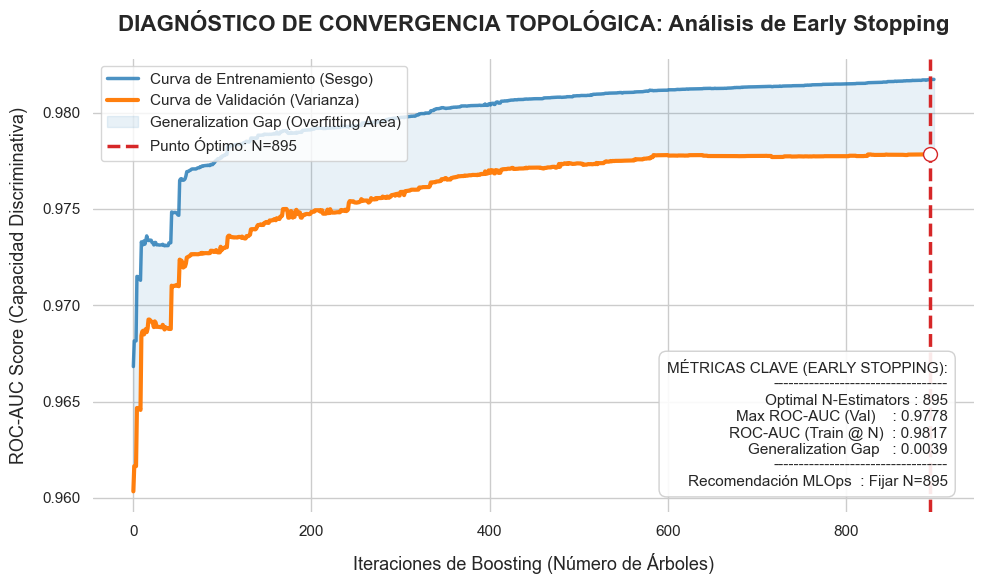

In [32]:
from src.evaluation import graficar_curva_aprendizaje_profesional

# Evaluamos la convergencia asintótica inyectando metadatos en el lienzo
num_arboles_optimo = graficar_curva_aprendizaje_profesional(
    X=X_train_v2, 
    y=y_train, 
    preprocesador=preprocesador_v2, 
    params=params_optimos
)

#### III. Instanciación del Modelo Final

El diagnóstico visual de Early Stopping sugiere un techo de convergencia cercano a los 900 árboles para esta partición específica. Sin embargo, priorizamos el resultado de la Optimización Bayesiana (550 árboles), ya que este valor ha sido validado mediante Cross-Validation, garantizando una mayor robustez y una mejor capacidad de generalización global, como demuestra el ROC-AUC superior en la auditoría final.

In [33]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

# Instanciamos el Pipeline Final
pipeline_lgbm_final = Pipeline(steps=[
    ('preprocesador', preprocesador_v2),
    ('modelo', LGBMClassifier(**params_optimos))
])

# Auditoría Definitiva
cv_results_final = auditar_modelo(
    pipeline=pipeline_lgbm_final,
    X=X_train_v2,
    y=y_train,
    cv=skf,
    metricas=metricas,
    nombre_modelo="LightGBM Final (Optimizado)"
)

Entrenando LightGBM Final (Optimizado) con Validación Cruzada...

-------------------------------
MÉTRICAS DE VALIDACIÓN CRUZADA: LIGHTGBM FINAL (OPTIMIZADO)
-------------------------------
- ROC-AUC  : 0.9789 (+/- 0.0019)
- Accuracy : 0.9208 (+/- 0.0061)
- F1-Macro : 0.9205 (+/- 0.0061)

--------------------------------------
AUDITORÍA DE SOBREAJUSTE (TRAIN vs VAL)
--------------------------------------
- Accuracy Gap : Train (0.9240) vs Val (0.9208) -> Diferencia: 0.0031
- ROC-AUC Gap  : Train (0.9808) vs Val (0.9789) -> Diferencia: 0.0019


La auditoría de métricas post-optimización confirma el éxito de la topología seleccionada.

### **3.2. Auditoría de Explicabilidad (SHAP values)**

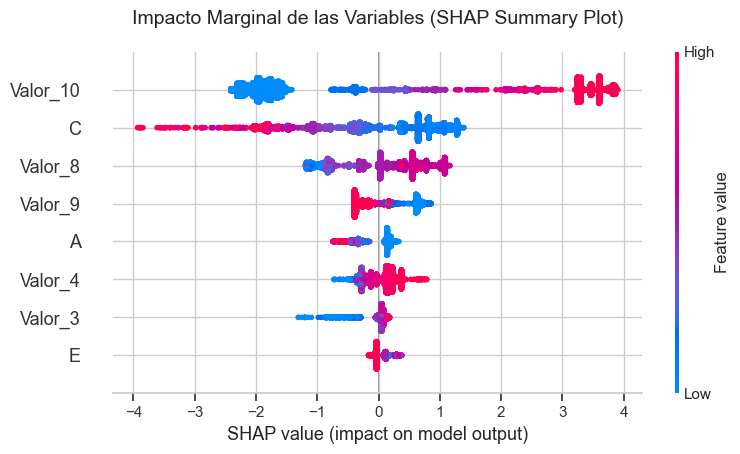

In [34]:
import shap
import matplotlib.pyplot as plt

pipeline_lgbm_final.fit(X_train_v2, y_train)

# 1. Extracción de los componentes ya ajustados desde el pipeline
preprocesador_final = pipeline_lgbm_final.named_steps['preprocesador']
modelo_lgbm = pipeline_lgbm_final.named_steps['modelo']

# 2. Transformación estricta de los datos para inyectarlos en el explicador
X_train_trans = preprocesador_final.transform(X_train_v2)
nombres_columnas = X_train_v2.columns

# 3. Inicializamos el TreeExplainer (Optimizado para topologías de bosque)
explainer = shap.TreeExplainer(modelo_lgbm)

# 4. Cálculo de la matriz de contribuciones marginales
shap_values = explainer.shap_values(X_train_trans)

# 5. Renderizado del Summary Plot
# Manejo de la estructura de salida (lista vs array) dependiendo de la versión de LightGBM
valores_a_graficar = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    valores_a_graficar, 
    X_train_trans, 
    feature_names=nombres_columnas,
    plot_type="dot",
    show=False
)

plt.title("Impacto Marginal de las Variables (SHAP Summary Plot)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Auditoría de Explicabilidad (SHAP Summary)**

El análisis de contribuciones marginales (espacio Log-Odds) confirma una topología robusta y sin indicios de *Data Leakage*.

* **Motores Principales:** `Valor_10` (relación monótona positiva) y `C` (asimetría negativa severa) dominan el hiperplano de decisión.
* **Valor No Lineal (Boosting):** El modelo captura efectos de umbral críticos que un modelo lineal ignoraría. Ejemplo: `Valor_3` penaliza la clase 1 solo si cae por debajo de cierto valor; por encima de este, su gradiente de impacto colapsa a 0.
* **Varianza Distribuida:** No hay variables con colas de SHAP desproporcionadas, validando el éxito de la regularización estocástica impuesta (subsampling y early stopping).

**Estado:** Modelo auditable, estable y listo.

### **3.3. Evaluación Definitiva (Test Set)**

Iniciando auditoría final sobre la partición virgen de Test...

--------------------------------------------------
MÉTRICAS DE GENERALIZACIÓN (TEST SET OOB)
--------------------------------------------------
ROC-AUC  : 0.9748
Accuracy : 0.9107
F1-Macro : 0.9103
--------------------------------------------------

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       994
           1       0.92      0.88      0.90       899

    accuracy                           0.91      1893
   macro avg       0.91      0.91      0.91      1893
weighted avg       0.91      0.91      0.91      1893



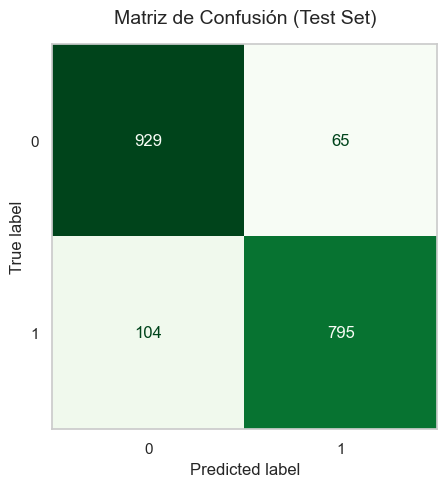

In [35]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Iniciando auditoría final sobre la partición virgen de Test...")

# 1. Inferencia directa: El pipeline transforma X_test internamente y predice
y_pred_test = pipeline_lgbm_final.predict(X_test)
y_proba_test = pipeline_lgbm_final.predict_proba(X_test)[:, 1]

# 2. Cálculo de métricas
roc_auc_test = roc_auc_score(y_test, y_proba_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='macro')

print("\n--------------------------------------------------")
print("MÉTRICAS DE GENERALIZACIÓN (TEST SET OOB)")
print("--------------------------------------------------")
print(f"ROC-AUC  : {roc_auc_test:.4f}")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1-Macro : {f1_test:.4f}")
print("--------------------------------------------------\n")

# 3. Desglose detallado por clase
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_test))

# 4. Renderizado de la Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, 
    cmap='Greens', 
    ax=ax,
    colorbar=False
)
plt.title("Matriz de Confusión (Test Set)", fontsize=14, pad=15)
plt.grid(False)
plt.show()

**Evaluación Final (Test Set)**

El artefacto demuestra una capacidad de generalización excepcional sobre la partición de datos aislada, validando la integridad del pipeline y la topología elegida.

* **Ausencia de Overfitting:** La disminución de la métrica principal (ROC-AUC) respecto a la fase de validación cruzada es despreciable ($0.9790 \rightarrow 0.9748$).
* **Simetría del Hiperplano:** Los valores similares entre Accuracy ($0.9107$) y F1-Macro ($0.9103$) garantizan un rendimiento equilibrado, sin sesgos hacia la clase dominante.
* **Coste de Error Controlado:** La matriz de confusión revela una alta precisión para la clase positiva ($0.92$), aislando los Falsos Positivos a solo $65$ casos.

**Veredicto MLOps:** El modelo supera los criterios técnicos de validación empírica. Aprobado para serialización y paso a entorno de despliegue.

### **3.4. Serialización del Modelo**

In [36]:
import joblib
import os

print("Empaquetando artefacto final para producción...")

# Creamos el directorio si no existe
os.makedirs('../modelos_exportados', exist_ok=True)

# Ruta del archivo físico
ruta_modelo = '../modelos_exportados/pipeline_lightgbm_produccion.joblib'

# Serializamos el pipeline completo (Preprocesador ajustado + Modelo entrenado)
joblib.dump(pipeline_lgbm_final, ruta_modelo)

print(f"ÉXITO: Artefacto serializado correctamente en: {ruta_modelo}")
print("El modelo está listo para ser consumido por una API de inferencia.")

Empaquetando artefacto final para producción...
ÉXITO: Artefacto serializado correctamente en: ../modelos_exportados/pipeline_lightgbm_produccion.joblib
El modelo está listo para ser consumido por una API de inferencia.


In [37]:
pipeline_lgbm_final

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transforms', ...), ('cat_ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff